# Graph Convolutional Network (GCN) Pipeline for ENZYMES Dataset

## Introduction

This assignment focuses on implementing Graph Convolutional Networks (GCNs) for graph classification using the ENZYMES dataset from PyTorch Geometric (PyG). You will explore graph structures, preprocess the data, implement GCN models (both manually and using PyG), and evaluate their performance.

Please fill in the missing code between the designated markers:

    ```Python
    ### Your code starts
    ```
    and
    ```Python
    ### Your code ends
    ```


## Dataset Description

### ENZYMES Dataset Overview

The **ENZYMES dataset** is a collection of **600 graphs**, where each graph represents a **protein**.  
The **nodes** in each graph correspond to **amino acids (residues)**, and **edges** represent **spatial closeness** between residues.  
The dataset is used for **graph classification**, where the goal is to predict the **enzyme class** of each protein.  
There are **six enzyme classes** in total.

#### **Graph Structure**
Each graph has:

- **Nodes**: Amino acids (**average ~32 nodes per graph**)
- **Edges**: Spatial connectivity (**~62 edges per graph**)
- **Node Features**: **21-dimensional feature vectors per node**
- **Graph Labels**: One of **six enzyme classes**

#### **Use Cases**
This dataset is widely used in **biochemical function prediction** and is suitable for training **Graph Neural Networks (GNNs)** such as **Graph Convolutional Networks (GCN)**.


## 1. Device Selection

In [15]:
import torch

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print()

print("-------- Checking GPU -------------")
print("cuda available:", torch.cuda.is_available())
print("device count:", torch.cuda.device_count())
print("GPU:", torch.cuda.get_device_name(0))
print("capability:", torch.cuda.get_device_capability(0))
print("memory GB (approx):", torch.cuda.get_device_properties(0).total_memory/1024**3)
print("PyTorch was built with CUDA", torch.version.cuda) #CUDA version pytorch library was compiled for
print("Torch version:", torch.__version__)
print('Arch List:', torch.cuda.get_arch_list()) #return list of CUDA architectures pytorch supports
print()

#nvidia-smi #check CUDA version
#conda list #list of installed packages and their versions in the current conda environment


Using device: cuda

-------- Checking GPU -------------
cuda available: True
device count: 1
GPU: NVIDIA GeForce RTX 5070 Ti
capability: (12, 0)
memory GB (approx): 15.92047119140625
PyTorch was built with CUDA 12.8
Torch version: 2.8.0+cu128
Arch List: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']



## 2. Package Installation

To use PyTorch Geometric (PyG), we need to install PyTorch, torch_geometric, and the required dependencies.

In [16]:
#install PyTorch with specific version (2.8) and CUDA support (cu128)
#pip install torch==2.8.0 torchvision==0.23.0 torchaudio==2.8.0 --index-url https://download.pytorch.org/whl/cu128

#install pytorch geometric dependencies compatible with PyTorch 2.8 and CUDA 12.8
#pip install torch-geometric torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.8.0+cu128.html

## 3. Prepare Dataset

We will download the ENZYMES dataset using TUDataset from PyTorch Geometric and prepare it for training.

In [17]:
from torch_geometric.datasets import TUDataset

# Load the ENZYMES dataset
dataset = TUDataset(root='data/ENZYMES', name='ENZYMES')

# Move the dataset to the selected device (CPU/GPU)
dataset = dataset.shuffle()

print(f"Dataset loaded: {dataset}")
print(f"Number of graphs: {len(dataset)}")
print(f"Number of classes: {dataset.num_classes}")
print(f"Node feature dimension: {dataset.num_node_features}")

Dataset loaded: ENZYMES(600)
Number of graphs: 600
Number of classes: 6
Node feature dimension: 3


## 4. Explore the Data

### Instruction:
Before training, we should explore the dataset to understand its structure:

- **Total number of graphs**
- **Number of nodes per graph**
- **Number of edges per graph**
- **Node features and labels**

In [18]:
import numpy as np

# Get basic dataset statistics
### Your code starts
num_graphs = len(dataset)
num_classes = dataset.num_classes
num_node_features = dataset.num_node_features
### Your code ends

# Collect statistics about node and edge counts
num_nodes_list = []
num_edges_list = []

for graph in dataset:
    num_nodes_list.append(graph.num_nodes) #number of nodes in the graph
    num_edges_list.append(graph.num_edges) #number of edges in the graph

print(f"Total Graphs: {num_graphs}")
print(f"Number of Classes: {num_classes}")
print(f"Node Feature Dimension: {num_node_features}")

print(f"Avg. Nodes per Graph: {np.mean(num_nodes_list):.2f}")
print(f"Avg. Edges per Graph: {np.mean(num_edges_list):.2f}")

# Visualize the first graph
first_graph = dataset[0]
print(f"First Graph Details:\n {first_graph}")


Total Graphs: 600
Number of Classes: 6
Node Feature Dimension: 3
Avg. Nodes per Graph: 32.63
Avg. Edges per Graph: 124.27
First Graph Details:
 Data(edge_index=[2, 76], x=[20, 3], y=[1])


## 5. Preprocessing (Normalization, Splitting into Train/Validation/Test)

### Instruction:
- Shuffle the dataset before splitting.
- Normalize node features to ensure better convergence.
- Split the dataset into train (80%), validation (10%), and test (10%) sets.

In [19]:
import torch
from torch_geometric.transforms import NormalizeFeatures
from torch.utils.data import random_split

# Normalize the node features
### Your code starts
dataset = TUDataset(root="data/ENZYMES", name="ENZYMES", transform=NormalizeFeatures())
dataset = dataset.shuffle()

# Split the dataset
num_graphs = len(dataset)
train_size = int(0.8 * num_graphs) #80% graphs for training (n=600*0.8=480)
val_size = int(0.1 * num_graphs) #10% graphs for validation (n=600*0.1=60)
test_size = num_graphs - train_size - val_size #10% graphs for testing (n=600*0.1=60)
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
### Your code ends

print(f"Train size: {len(train_dataset)}, Validation size: {len(val_dataset)}, Test size: {len(test_dataset)}")


Train size: 480, Validation size: 60, Test size: 60


## 6. GCN Model Definition

Instruction:
We will implement two GCN models:

1. GCN by hand (using basic matrix operations)
2. GCN using PyG (utilizing torch_geometric.nn.GCNConv)

### 6.1 Implementing GCN by Hand

We will manually implement the **graph convolution operation** **without** using `torch_geometric.nn`.

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.utils import add_self_loops, degree
from torch_geometric.nn import global_mean_pool  # For graph-level pooling

class GCNHandmade(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCNHandmade, self).__init__()
        ### Your code starts
        self.fc1 =  nn.Linear(in_channels, hidden_channels)  # node features -> hidden representation
        self.fc2 =  nn.Linear(hidden_channels, hidden_channels)  # Second graph convolution layer
        self.classifier =  nn.Linear(hidden_channels, out_channels)  # Final graph-level classification layer
        ### Your code ends

    def forward(self, x, edge_index, batch):
        ### Your code starts

        # Step 1: Add self-loops
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0)) #each node include itself as a neighbor

        # Step 2: Compute degree matrix
        row, col = edge_index #unpack edge_index into source (row) and target (col) nodes
        deg = degree(col, x.size(0), dtype=x.dtype)  # compute degree of each node (i.e., # of neighbors)

        # Step 3: Normalize adjacency matrix
        deg_inv_sqrt = deg.pow(-0.5) # D^(-1/2) for symmetric normalization
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0
        norm = deg_inv_sqrt[row] * deg_inv_sqrt[col] #normalization factor for each edge (D^(-1/2) * A * D^(-1/2))

        # Step 4: Message Passing [nodes, features]
        x = self.fc1(x) # linear transformation [nodes, hidden]
        x = norm.view(-1,1) * x[row] # normalize [edges, hidden]
        x = torch.zeros_like(x).scatter_add_(0, col.unsqueeze(-1).expand_as(x), x) # aggregate messages from neighbors to each node [nodes + edges, hidden]
        x = F.relu(x) # activation function; [nodes + edges, hidden]

        x = self.fc2(x)
        x = norm.view(-1,1) * x[row]
        x = torch.zeros_like(x).scatter_add_(0, col.unsqueeze(-1).expand_as(x), x)
        x = F.relu(x)

        # Step 5: **Graph-level pooling** (Aggregate node representations into a single vector per graph)
        x = global_mean_pool(x, batch)  #average node within each graph 

        # Step 6: Final classification
        out = self.classifier(x) #apply final linear layer to get class logits

        ### Your code ends

        return F.log_softmax(out, dim=1) #returns log probabilities for each class per graph

    '''
    def new_method(self, x, edge_index):
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0)) # Graph-level classification output
    '''

## 6.2 Implementing GCN using PyG

Now, we define a GCN model using PyG's built-in layers.

In [21]:
from torch_geometric.nn import GCNConv
from torch_geometric.nn import GCNConv, global_mean_pool

class GCNPyG(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCNPyG, self).__init__()
        ### Your code starts
        self.conv1 = GCNConv(in_channels, hidden_channels)  # First GCN layer
        self.conv2 = GCNConv(hidden_channels, hidden_channels)  # Second GCN layer
        self.classifier = nn.Linear(hidden_channels, out_channels)  # Graph-level classifier
        ### Your code ends

    def forward(self, x, edge_index, batch):
        ### Your code starts
        
        # Step 1: apply GCN layers with activation functions
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)

        # Step 2: Graph-level pooling (aggregate node embeddings per graph)
        x_graph = global_mean_pool(x, batch)  
        
        ### Your code ends
        
        # Final graph-level classification
        out = self.classifier(x_graph)
        #return F.log_softmax(out, dim=1)
        return out



## 7. Training the Model

We will train both models using the same pipeline and store hyperparameters in a dictionary for easy tuning.

In [22]:
# Define hyperparameters
hyperparams = {
    "hidden_channels": 64,
    "learning_rate": 0.01,
    "epochs": 50,
    "batch_size": 32
}

# Define loss function and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train(model, train_dataset, val_dataset):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=hyperparams["learning_rate"])
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(hyperparams["epochs"]):
        model.train()
        total_loss = 0

        for graph in train_dataset:
            graph = graph.to(device)
            optimizer.zero_grad()
            out = model(graph.x, graph.edge_index, graph.batch)  # Pass batch indices
            loss = loss_fn(out, graph.y)  # Graph-level loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_dataset):.4f}")

    print("Training Complete!")


## 8. Evaluating the Model

We will evaluate both models and plot accuracy results.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def evaluate(model, test_dataset):
    model.eval()
    all_preds = [] #to store PREDICTED labels for confusion matrix
    all_labels = [] #to store TRUE labels for confusion matrix
    correct = 0
    total = 0

    with torch.no_grad():
        for graph in test_dataset:
            graph = graph.to(device)

            out = model(graph.x, graph.edge_index, graph.batch)  # **Pass batch index**
            pred = out.argmax(dim=1)
            correct += (pred == graph.y).sum().item()
            total += graph.y.size(0)

            #NEW: Collect predictions and true labels for confusion matrix
            all_preds.append(pred.item())
            all_labels.append(graph.y.item())
                             
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    #Evaluation Metrics                   
    accuracy = correct / total
    print()
    print("------------------ Evaluation Metrics ---------------------")
    print(f"Test Accuracy: {accuracy * 100:.2f}%")

    report = classification_report(all_labels, all_preds, zero_division=0, digits=4)
    print("Classification Report:\n", report)

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix ({model.__class__.__name__})')
    plt.show()

    return accuracy


Training GCN (Handmade)...
Epoch 1, Loss: 1.8039
Epoch 2, Loss: 1.7866
Epoch 3, Loss: 1.7789
Epoch 4, Loss: 1.7728
Epoch 5, Loss: 1.7672
Epoch 6, Loss: 1.7628
Epoch 7, Loss: 1.7572
Epoch 8, Loss: 1.7513
Epoch 9, Loss: 1.7450
Epoch 10, Loss: 1.7395
Epoch 11, Loss: 1.7352
Epoch 12, Loss: 1.7323
Epoch 13, Loss: 1.7289
Epoch 14, Loss: 1.7267
Epoch 15, Loss: 1.7253
Epoch 16, Loss: 1.7239
Epoch 17, Loss: 1.7226
Epoch 18, Loss: 1.7213
Epoch 19, Loss: 1.7197
Epoch 20, Loss: 1.7184
Epoch 21, Loss: 1.7166
Epoch 22, Loss: 1.7143
Epoch 23, Loss: 1.7127
Epoch 24, Loss: 1.7099
Epoch 25, Loss: 1.7124
Epoch 26, Loss: 1.7079
Epoch 27, Loss: 1.7105
Epoch 28, Loss: 1.7069
Epoch 29, Loss: 1.7081
Epoch 30, Loss: 1.7061
Epoch 31, Loss: 1.7051
Epoch 32, Loss: 1.7086
Epoch 33, Loss: 1.7047
Epoch 34, Loss: 1.7037
Epoch 35, Loss: 1.7056
Epoch 36, Loss: 1.7033
Epoch 37, Loss: 1.7022
Epoch 38, Loss: 1.7013
Epoch 39, Loss: 1.7033
Epoch 40, Loss: 1.7016
Epoch 41, Loss: 1.7016
Epoch 42, Loss: 1.7008
Epoch 43, Loss:

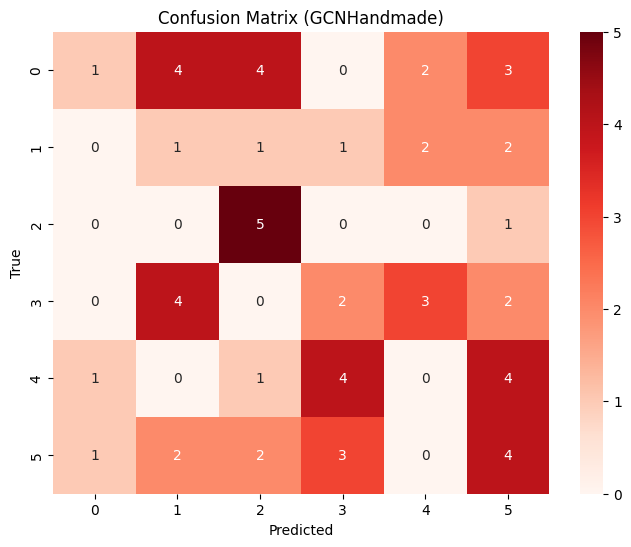


Evaluating GCN (PyG)...

------------------ Evaluation Metrics ---------------------
Test Accuracy: 23.33%
Classification Report:
               precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        14
           1     0.2000    0.1429    0.1667         7
           2     0.3636    0.6667    0.4706         6
           3     0.5000    0.0909    0.1538        11
           4     0.1111    0.2000    0.1429        10
           5     0.2500    0.5000    0.3333        12

    accuracy                         0.2333        60
   macro avg     0.2375    0.2667    0.2112        60
weighted avg     0.2199    0.2333    0.1852        60



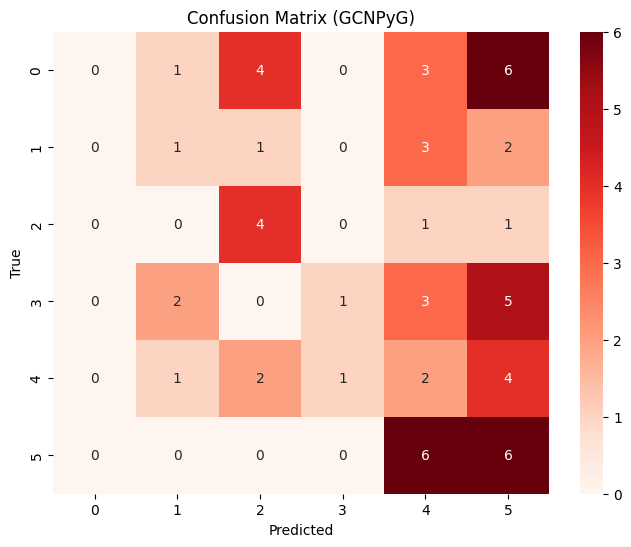

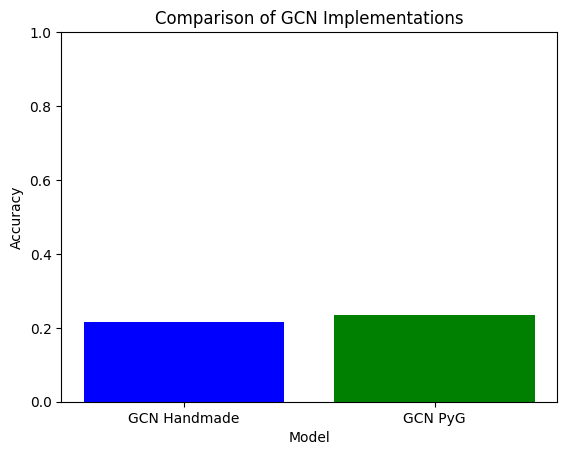

In [24]:
# Train and evaluate both models
# a) Train both models
gcn_handmade = GCNHandmade(dataset.num_node_features, hyperparams["hidden_channels"], dataset.num_classes)
gcn_pyg = GCNPyG(dataset.num_node_features, hyperparams["hidden_channels"], dataset.num_classes)

print("\nTraining GCN (Handmade)...")
train(gcn_handmade, train_dataset, val_dataset)

print("\nTraining GCN (PyG)...")
train(gcn_pyg, train_dataset, val_dataset)

# b) Evaluate both models
print("\nEvaluating GCN (Handmade)...")
acc_handmade = evaluate(gcn_handmade, test_dataset) #get evaluation metrics (accuracy, precision, recall, F1-score) & confusion matrix
print("\nEvaluating GCN (PyG)...")
acc_pyg = evaluate(gcn_pyg, test_dataset)

# Plot results
models = ["GCN Handmade", "GCN PyG"]
accuracies = [acc_handmade, acc_pyg]

plt.bar(models, accuracies, color=['blue', 'green'])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Comparison of GCN Implementations")
plt.ylim([0, 1])
plt.show()


## 9. Making Predictions

We will make predictions on test samples and visualize them.

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import seaborn as sns

def make_predictions_and_plot(model, test_dataset):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for graph in test_dataset:
            graph = graph.to(device)
            out = model(graph.x, graph.edge_index, graph.batch)  # Pass batch index
            prob = torch.exp(out)  # Convert log-softmax to probabilities
            pred = prob.argmax(dim=1)

            all_preds.append(pred.item())
            all_labels.append(graph.y.item())
            all_probs.append(prob[:, 1].item())  # Probabilities for class 1 (binary case)

    # Convert to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    ## ✅ **Confusion Matrix Plot**
    ### Your code starts
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(6), yticklabels=range(6))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f'Confusion Matrix ({model.__class__.__name__})')

    plt.show()

    ## ✅ **Classification Report**
    print("Classification Report:\n", classification_report(all_labels, all_preds, digits=4, zero_division=0))

    ## ✅ **ROC Curve & AUC Score**
    if len(set(all_labels)) == 2:  # Only compute if binary classification
        auc_score = roc_auc_score(all_labels, all_probs)
        fpr, tpr, _ = roc_curve(all_labels, all_probs)
        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
        plt.plot([0,1], [0,1], linestyle='--', color='gray')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend()
        plt.show()
        print(f"AUC Score: {auc_score:.4f}")

    print(f"Predictions: {all_preds}")
    print(f"True Labels: {all_labels}")

    return all_preds, all_labels


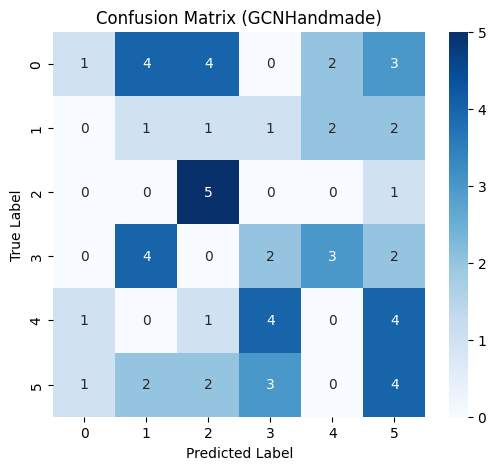

Classification Report:
               precision    recall  f1-score   support

           0     0.3333    0.0714    0.1176        14
           1     0.0909    0.1429    0.1111         7
           2     0.3846    0.8333    0.5263         6
           3     0.2000    0.1818    0.1905        11
           4     0.0000    0.0000    0.0000        10
           5     0.2500    0.3333    0.2857        12

    accuracy                         0.2167        60
   macro avg     0.2098    0.2605    0.2052        60
weighted avg     0.2135    0.2167    0.1851        60

Predictions: [2 5 1 0 5 1 3 2 2 5 5 5 3 1 2 4 5 5 1 5 3 2 4 2 2 5 3 2 5 0 2 3 5 1 1 3 2
 1 1 1 4 5 3 5 4 3 1 5 4 2 2 5 0 2 1 3 5 3 4 4]
True Labels: [2 0 1 0 2 0 4 4 5 5 5 3 4 0 0 3 3 1 5 5 3 2 1 0 2 4 4 0 0 4 2 1 4 3 3 5 1
 3 0 3 0 1 3 5 3 4 0 4 3 0 5 0 5 2 5 5 4 5 0 1]


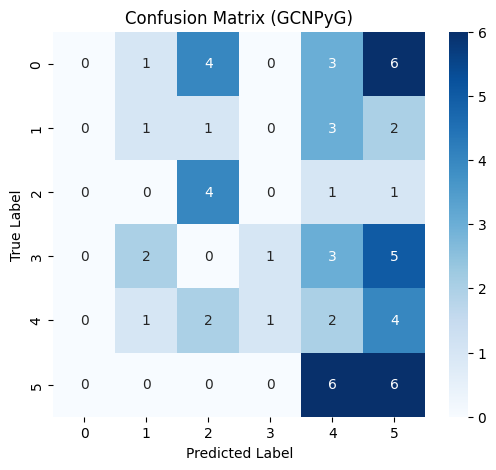

Classification Report:
               precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        14
           1     0.2000    0.1429    0.1667         7
           2     0.3636    0.6667    0.4706         6
           3     0.5000    0.0909    0.1538        11
           4     0.1111    0.2000    0.1429        10
           5     0.2500    0.5000    0.3333        12

    accuracy                         0.2333        60
   macro avg     0.2375    0.2667    0.2112        60
weighted avg     0.2199    0.2333    0.1852        60

Predictions: [2 1 1 2 5 5 3 2 4 5 5 3 4 5 2 4 5 5 5 5 5 2 4 2 2 5 5 4 5 2 2 4 5 1 1 4 2
 5 5 5 4 5 5 5 4 4 5 1 4 2 4 5 4 4 5 4 5 4 4 4]
True Labels: [2 0 1 0 2 0 4 4 5 5 5 3 4 0 0 3 3 1 5 5 3 2 1 0 2 4 4 0 0 4 2 1 4 3 3 5 1
 3 0 3 0 1 3 5 3 4 0 4 3 0 5 0 5 2 5 5 4 5 0 1]


(array([2, 1, 1, 2, 5, 5, 3, 2, 4, 5, 5, 3, 4, 5, 2, 4, 5, 5, 5, 5, 5, 2,
        4, 2, 2, 5, 5, 4, 5, 2, 2, 4, 5, 1, 1, 4, 2, 5, 5, 5, 4, 5, 5, 5,
        4, 4, 5, 1, 4, 2, 4, 5, 4, 4, 5, 4, 5, 4, 4, 4]),
 array([2, 0, 1, 0, 2, 0, 4, 4, 5, 5, 5, 3, 4, 0, 0, 3, 3, 1, 5, 5, 3, 2,
        1, 0, 2, 4, 4, 0, 0, 4, 2, 1, 4, 3, 3, 5, 1, 3, 0, 3, 0, 1, 3, 5,
        3, 4, 0, 4, 3, 0, 5, 0, 5, 2, 5, 5, 4, 5, 0, 1]))

In [26]:
make_predictions_and_plot(gcn_handmade, test_dataset) 
make_predictions_and_plot(gcn_pyg, test_dataset)

# Key findings and observations?